In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
FIG = ROOT / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

# Phase 1 — Column standardization and selection

Results are produced by `python -m src.columns`; this notebook shows them.

## 1. Header-mapping accuracy (59 gold headers from 7 files)

In [2]:
acc = pd.read_csv(ROOT/'reports'/'phase1_mapping_accuracy.csv'); acc

,method,accuracy,llm_calls
0,rules only (header keywords),0.898,0
1,"embeddings, header only",0.797,0
2,"embeddings, header + 5 samples",0.644,0
3,LLM only (qwen3:8b),0.949,59
4,embeddings (header + samples) + LLM if cosine < 0.3,0.729,8
5,embeddings (header + samples) + LLM if cosine < 0.4,0.864,24
6,embeddings (header + samples) + LLM if cosine < 0.5,0.949,46
7,embeddings (header + samples) + LLM if cosine < 0.6,0.949,57
8,embeddings (header only) + LLM if cosine < 0.3,0.915,13
9,embeddings (header only) + LLM if cosine < 0.4,0.966,29


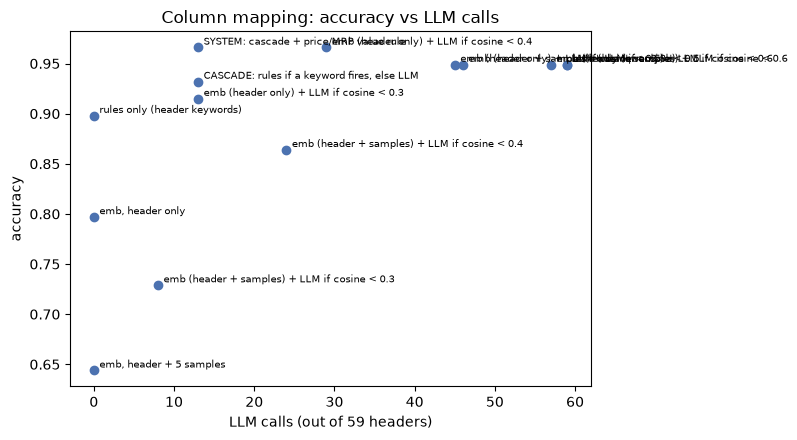

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(acc['llm_calls'], acc['accuracy'], color='#4c72b0')
for _, r in acc.iterrows():
    ax.annotate(r['method'].replace('embeddings', 'emb'), (r['llm_calls'], r['accuracy']), fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('LLM calls (out of 59 headers)'); ax.set_ylabel('accuracy'); ax.set_title('Column mapping: accuracy vs LLM calls')
fig.tight_layout(); fig.savefig(FIG/'phase1_accuracy_vs_calls.png', dpi=120)

## 2. Per-header predictions and errors

In [4]:
p = pd.read_csv(ROOT/'reports'/'phase1_mapping_predictions.csv')
cols = ['source','header','gold_field','rules','emb_header','embeddings','embeddings_cos','llm_only','system']
p[(p[['rules','embeddings','llm_only','system']].ne(p['gold_field'], axis=0)).any(axis=1)][cols]

,source,header,gold_field,rules,emb_header,embeddings,embeddings_cos,llm_only,system
0,bigbasket,index,id,other,id,id,0.213,id,id
1,bigbasket,product,product_name,other,product_name,other,0.409,product_name,product_name
3,bigbasket,sub_category,sub_category,sub_category,sub_category,category,0.622,sub_category,sub_category
6,bigbasket,market_price,mrp,price,price,price,0.492,mrp,mrp
7,bigbasket,type,other,other,product_name,other,0.439,sub_category,sub_category
9,bigbasket,description,description,description,description,other,0.444,description,description
14,flipkart,product_category_tree,category,category,category,category,0.606,other,category
15,flipkart,pid,id,other,id,id,0.258,id,id
16,flipkart,retail_price,mrp,price,mrp,price,0.516,price,mrp
18,flipkart,image,other,other,product_name,description,0.276,other,other


## 3. Automatic column selection (R2)

In [5]:
sel = pd.read_csv(ROOT/'reports'/'phase1_column_selection.csv')
sel[['source','column','avg_tokens','unique_ratio','alpha_ratio','entropy','url_ratio','selected','role','cluster_text','reason']]

,source,column,avg_tokens,unique_ratio,alpha_ratio,entropy,url_ratio,selected,role,cluster_text,reason
0,abt,id,1.00,1.000,0.000,10.08,0.000,False,NaN,0,"mostly non-letters (0% letters: ids, prices, codes); too short (1.0 tokens: ..."
1,abt,name,9.07,1.000,0.726,10.08,0.000,True,primary (name),1,"free text, 9.07 tokens, 100% unique, 73% letters"
2,abt,description,36.19,1.000,0.757,10.08,0.000,True,secondary (context),1,"free text, 36.19 tokens, 100% unique, 76% letters"
3,abt,price,1.00,0.397,0.000,6.70,0.000,False,NaN,0,"mostly empty (39% filled); mostly non-letters (0% letters: ids, prices, code..."
4,amazon,id,1.00,1.000,0.523,10.41,0.000,False,NaN,0,"mostly non-letters (52% letters: ids, prices, codes); too short (1.0 tokens:..."
5,amazon,title,5.72,0.987,0.779,10.39,0.000,True,primary (name),1,"free text, 5.72 tokens, 99% unique, 78% letters"
6,amazon,description,217.06,0.982,0.822,10.24,0.015,True,secondary (context),1,"free text, 217.06 tokens, 98% unique, 82% letters"
7,amazon,manufacturer,1.77,0.257,0.933,7.16,0.000,False,NaN,0,"too short (1.77 tokens: a label, not free text); low uniqueness (26%: a cate..."
8,amazon,price,1.00,0.178,0.000,5.74,0.000,False,NaN,0,"mostly non-letters (0% letters: ids, prices, codes); too short (1.0 tokens: ..."
9,bigbasket,index,1.00,1.000,0.000,14.75,0.000,False,NaN,0,"mostly non-letters (0% letters: ids, prices, codes); too short (1.0 tokens: ..."


## 4. Mapping used for the four output files, and the identical output schema

In [6]:
pd.read_csv(ROOT/'reports'/'phase1_mappings_used.csv')

,source,header,predicted,decided_by
0,bigbasket,index,id,llm
1,bigbasket,product,product_name,llm
2,bigbasket,category,category,rules
3,bigbasket,sub_category,sub_category,rules
4,bigbasket,brand,brand,rules
5,bigbasket,sale_price,price,rules + price/mrp rule
6,bigbasket,market_price,mrp,rules + price/mrp rule
7,bigbasket,type,sub_category,llm
8,bigbasket,rating,rating,rules
9,bigbasket,description,description,rules


In [7]:
for n in ['bigbasket', 'flipkart', 'off_india', 'abt']:
    d = pd.read_parquet(ROOT/'data'/'processed'/f'{n}_canonical.parquet')
    print(f'{n:10s}', d.shape, list(d.columns))
pd.read_parquet(ROOT/'data'/'processed'/'flipkart_canonical.parquet').drop(columns='description').head()

bigbasket  (27555, 11) ['source', 'product_name', 'brand', 'category', 'sub_category', 'price', 'mrp', 'quantity', 'description', 'rating', 'id']
flipkart   (20000, 11) ['source', 'product_name', 'brand', 'category', 'sub_category', 'price', 'mrp', 'quantity', 'description', 'rating', 'id']
off_india  (21189, 11) ['source', 'product_name', 'brand', 'category', 'sub_category', 'price', 'mrp', 'quantity', 'description', 'rating', 'id']
abt        (1081, 11) ['source', 'product_name', 'brand', 'category', 'sub_category', 'price', 'mrp', 'quantity', 'description', 'rating', 'id']


,source,product_name,brand,category,sub_category,price,mrp,quantity,rating,id
0,flipkart,Alisha Solid Women's Cycling Shorts,Alisha,Clothing,Women's Clothing,379.0,999.0,None,NaN,c2d766ca982eca8304150849735ffef9
1,flipkart,FabHomeDecor Fabric Double Sofa Bed,FabHomeDecor,Furniture,Living Room Furniture,22646.0,32157.0,None,NaN,7f7036a6d550aaa89d34c77bd39a5e48
2,flipkart,AW Bellies,AW,Footwear,Women's Footwear,499.0,999.0,None,NaN,f449ec65dcbc041b6ae5e6a32717d01b
3,flipkart,Alisha Solid Women's Cycling Shorts,Alisha,Clothing,Women's Clothing,267.0,699.0,None,NaN,0973b37acd0c664e3de26e97e5571454
4,flipkart,Sicons All Purpose Arnica Dog Shampoo,Sicons,Pet Supplies,Grooming,210.0,220.0,None,NaN,bc940ea42ee6bef5ac7cea3fb5cfbee7
